Baseflow package path added: /kaggle/input/datasets/kausar15027/bfi-measurement/baseflow-master
Station area file loaded.
Columns found:
['Station ID', 'NAME', 'Area']
   Station ID          NAME     Area
0      560051  Bad D??ben 1  6159.23
1      560021     Golzern 1  5428.98
2      560000      K??ssern  5352.45
3      566100         Erlln  2978.18
4      566085       Leisnig  2875.01

Cleaned station area table:
  Station_ID  Station_Name  Area_km2
0     560051  Bad D??ben 1   6159.23
1     560021     Golzern 1   5428.98
2     560000      K??ssern   5352.45
3     566100         Erlln   2978.18
4     566085       Leisnig   2875.01

Number of stations in Station_ID.csv: 240
Number of discharge CSV files found: 190
Number of matched stations to process: 167
Number of unmatched/skipped records: 96

Matched stations preview:
    Station_ID   Station_Name  Area_km2                  File
112     530020  Klingenthal 1   55.5419  530020_1960_2024.csv
82      550091  Buschm??hle 1  106.1440  

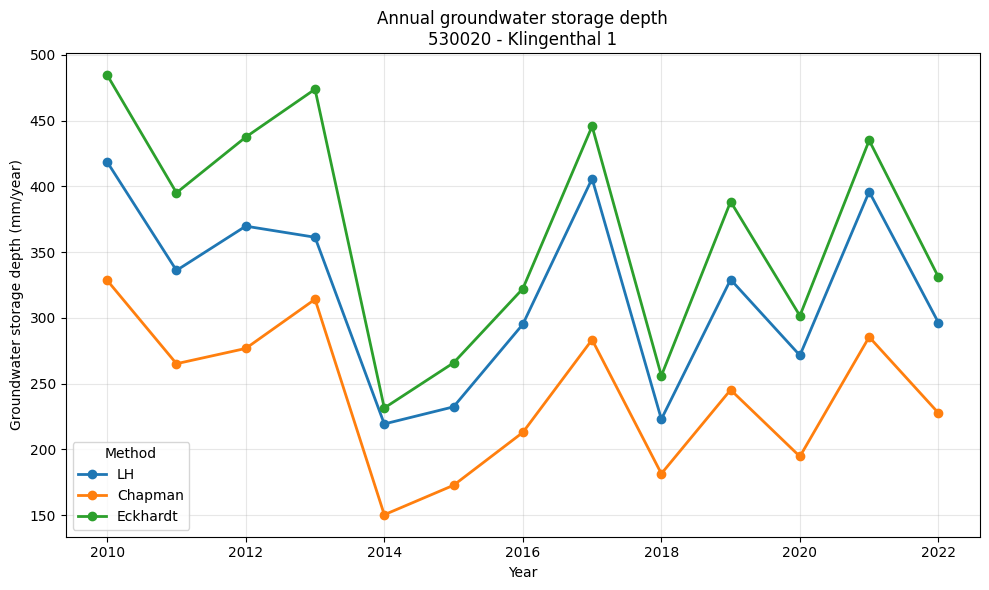

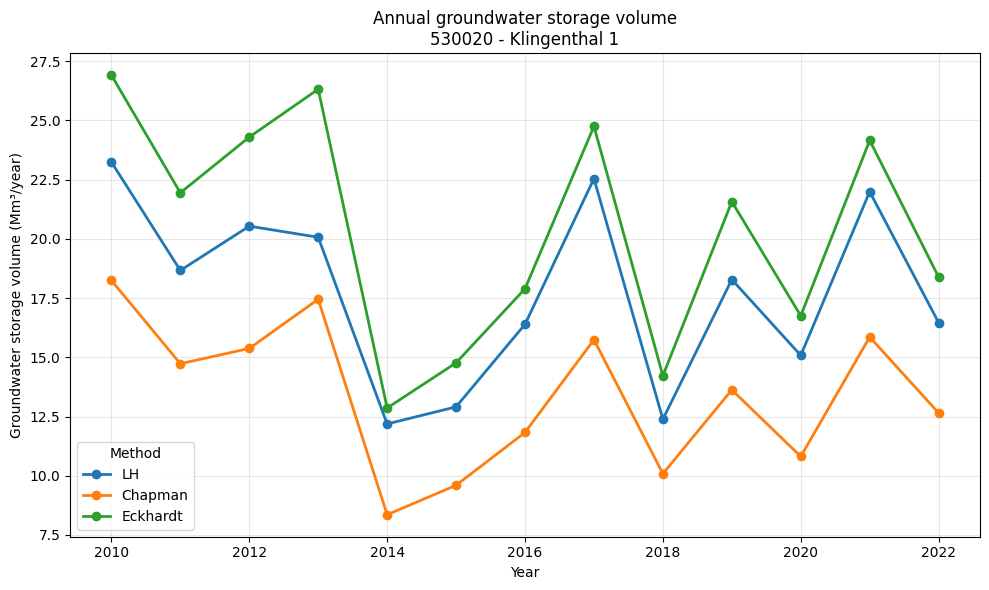

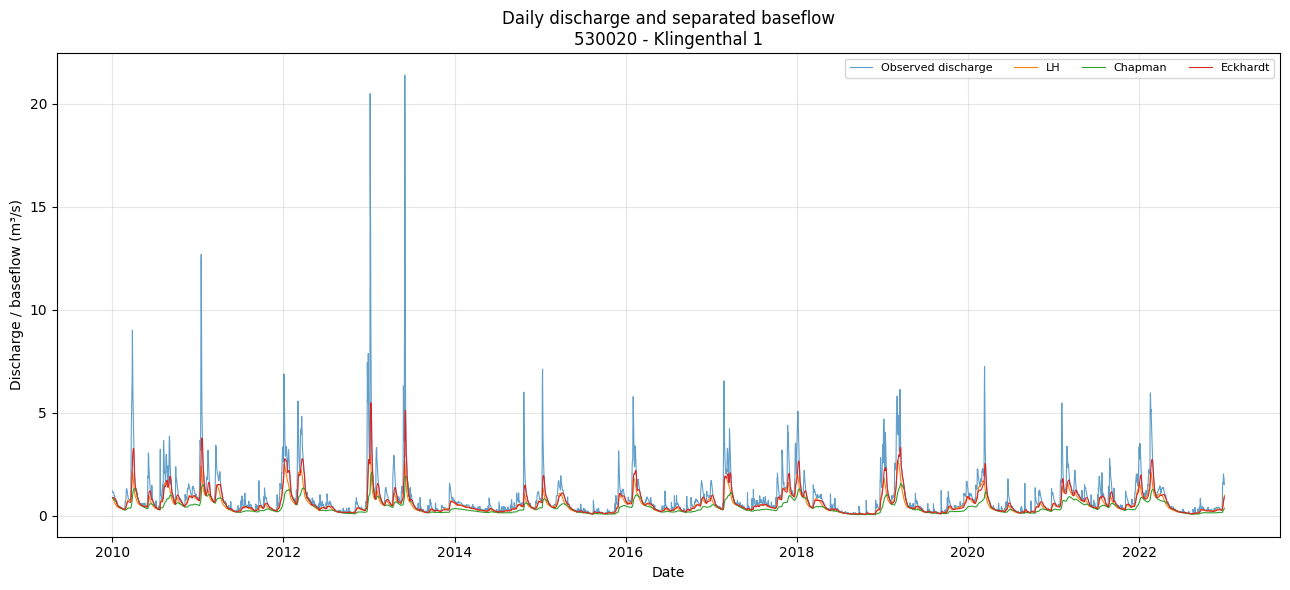


[2/167] Processing station 550091 - Buschm??hle 1


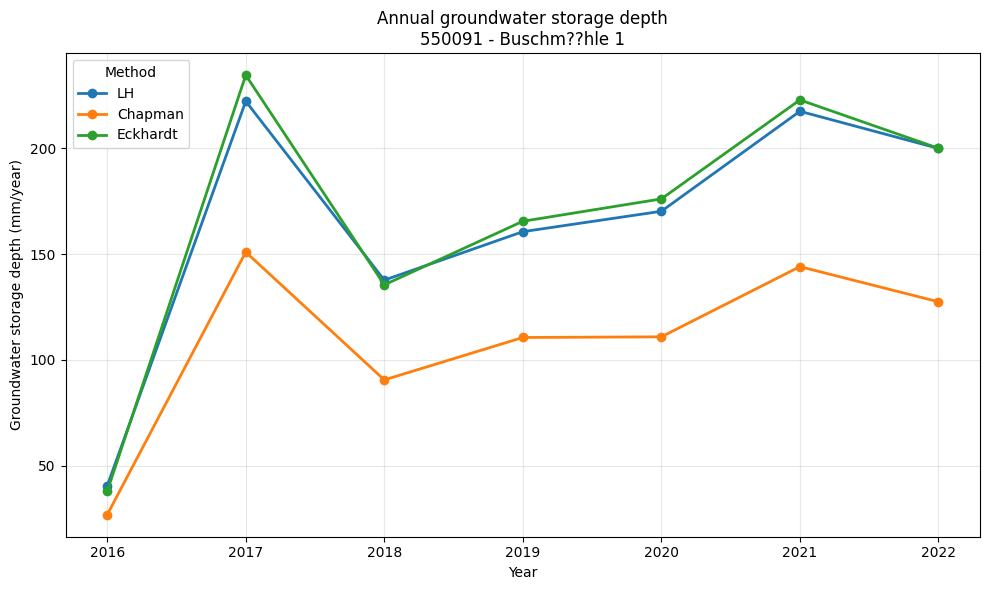

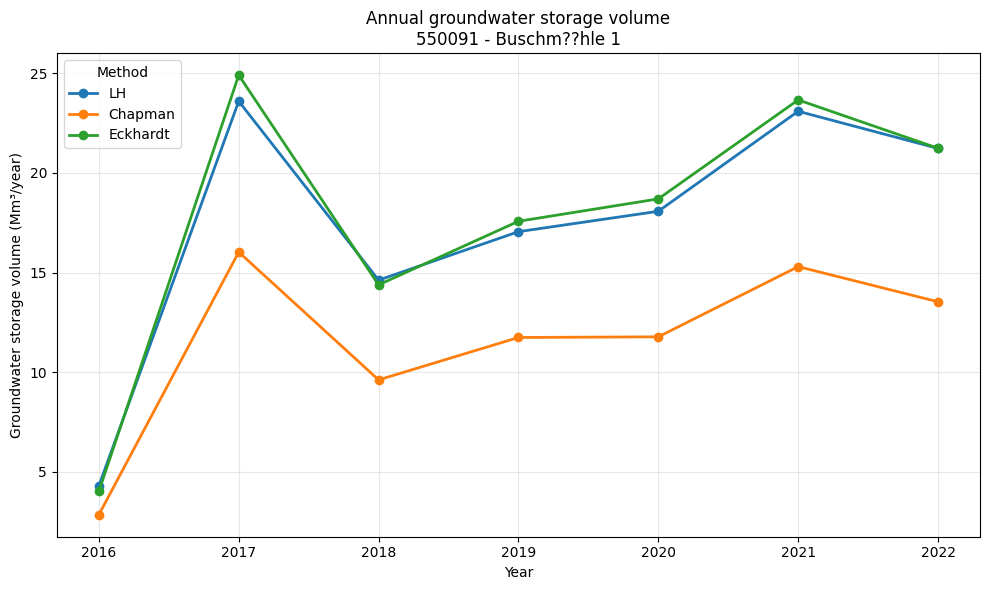

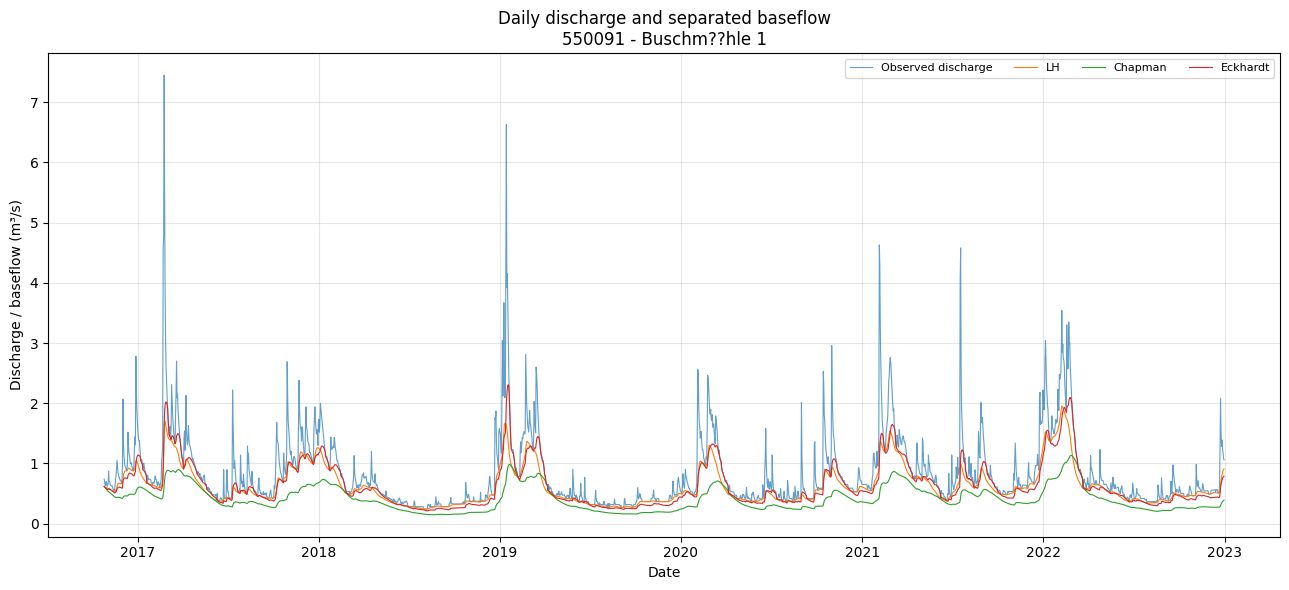


[3/167] Processing station 550110 - Kirnitzschtal


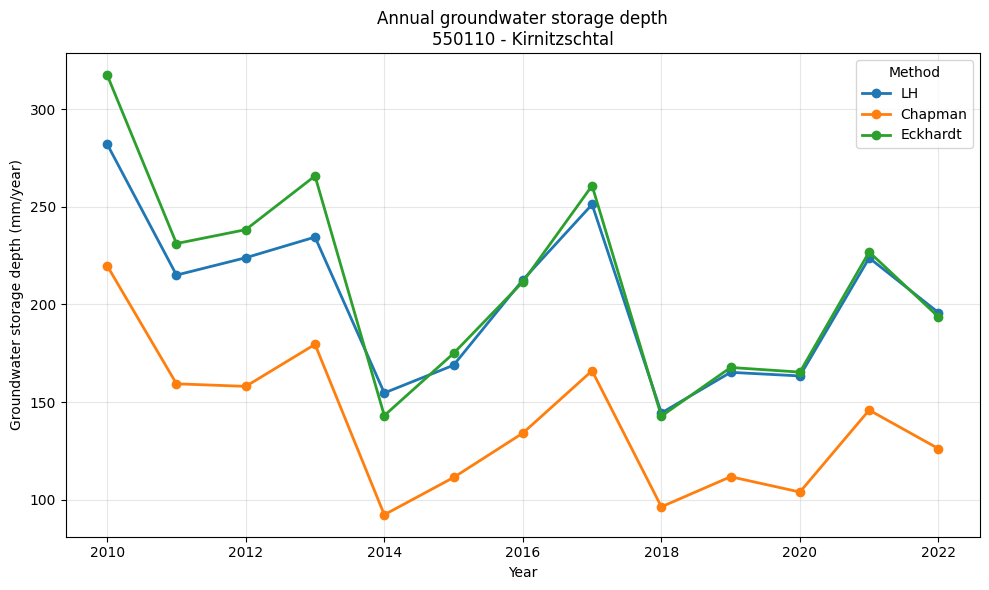

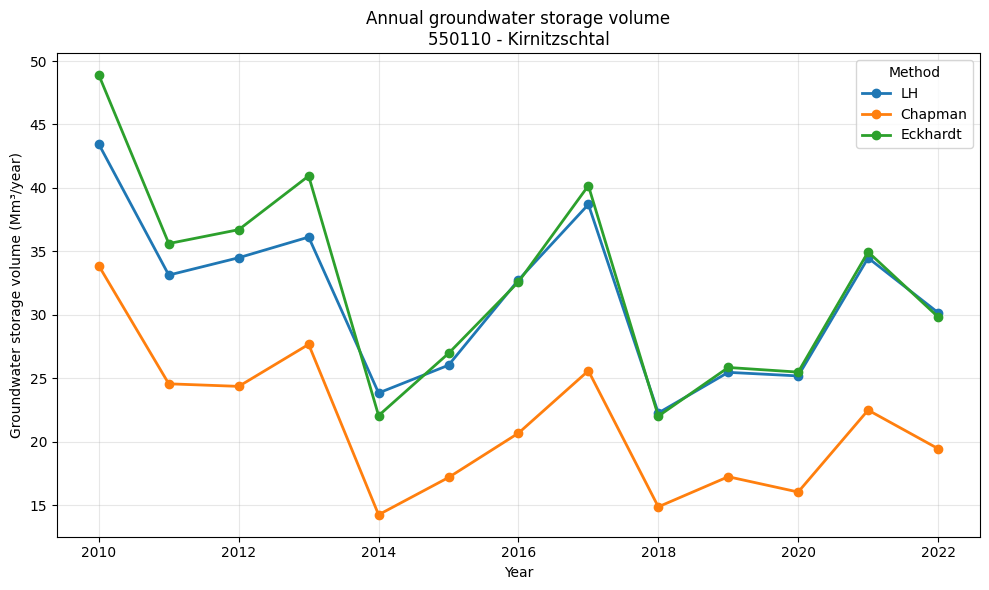

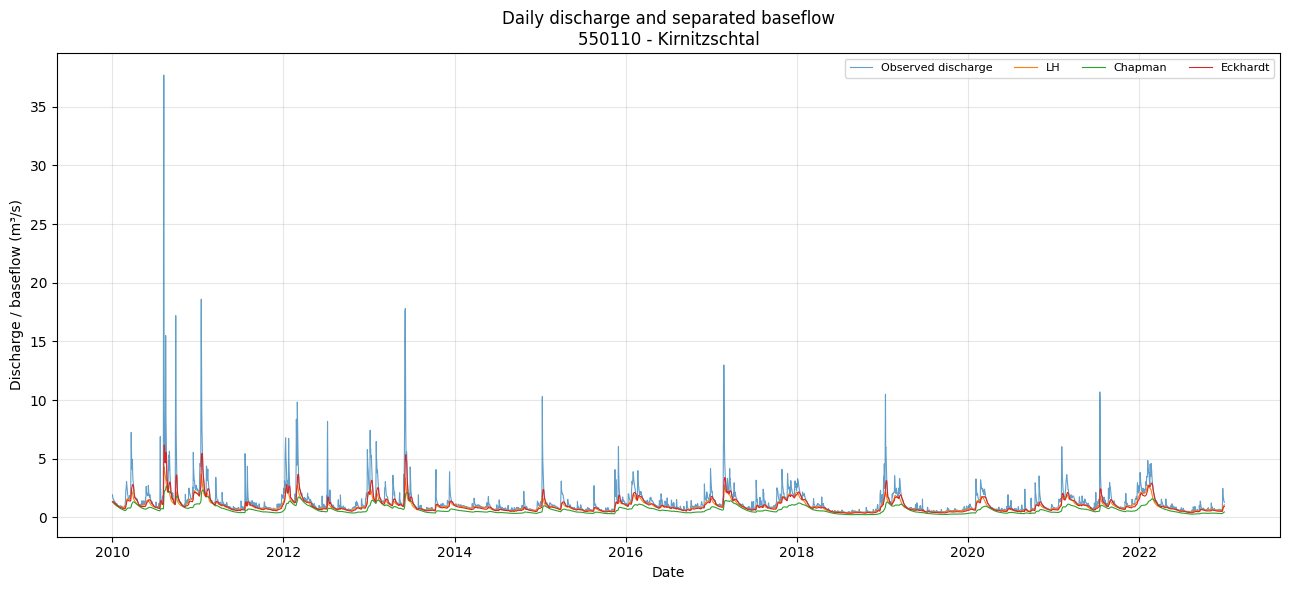


[4/167] Processing station 550190 - Porschdorf 1


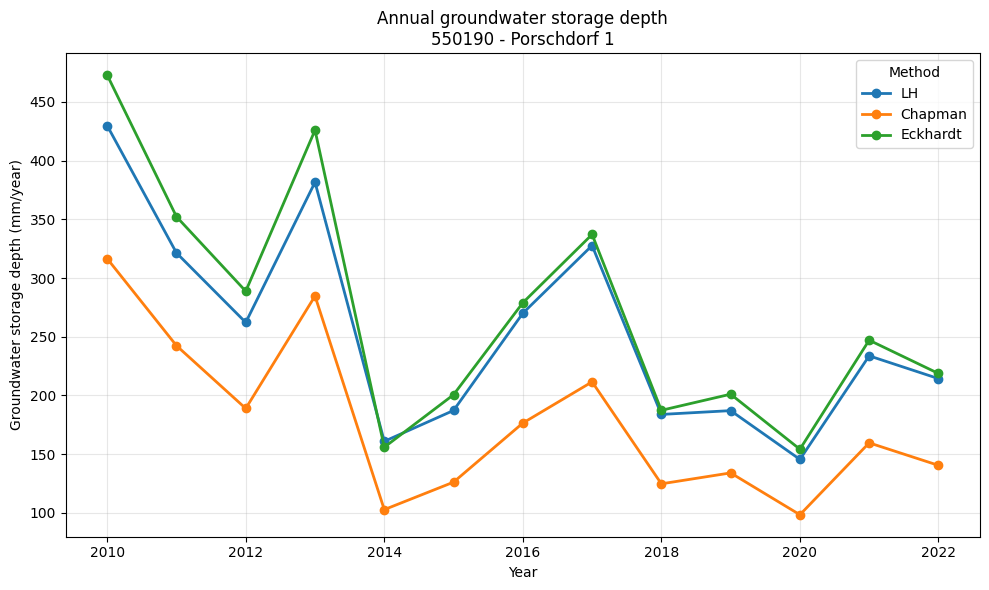

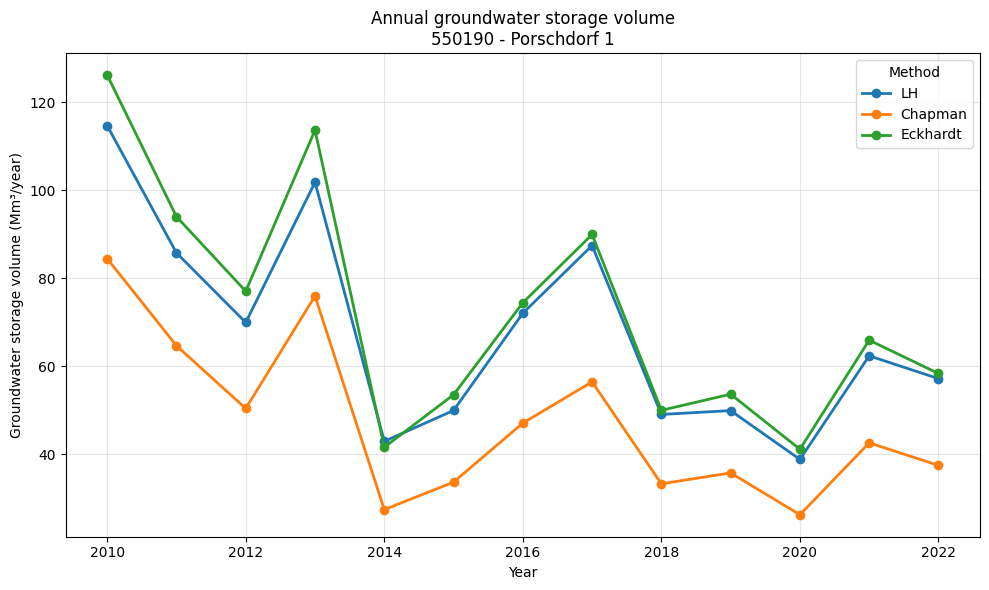

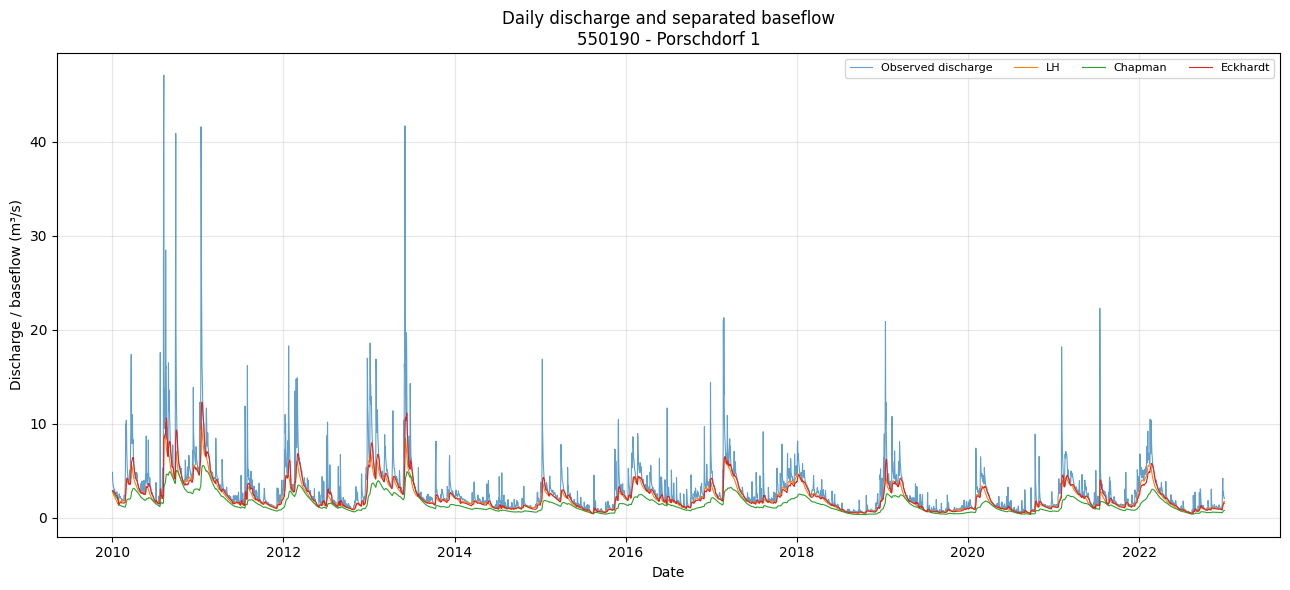


[5/167] Processing station 550290 - Sebnitz 3


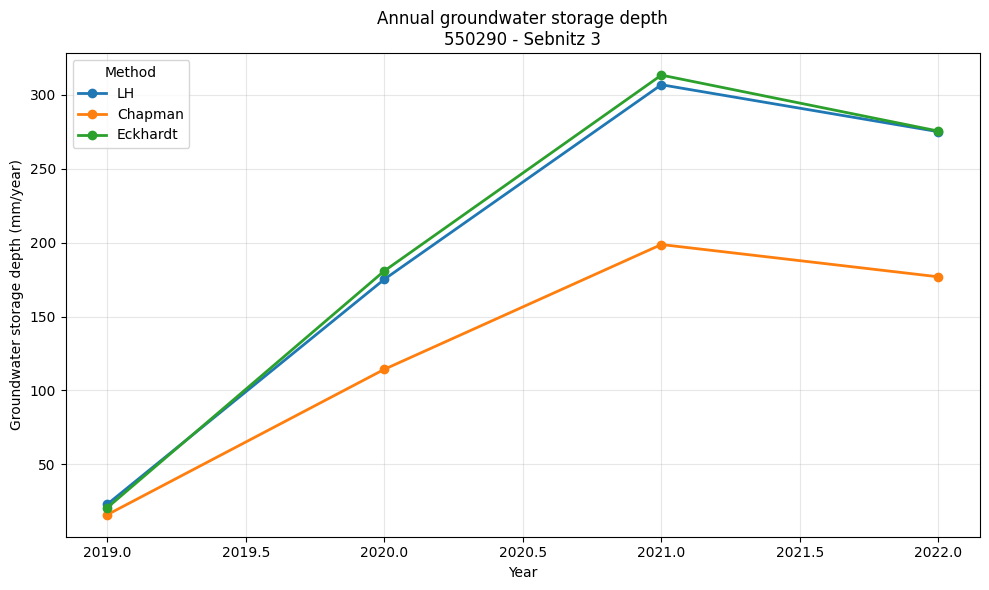

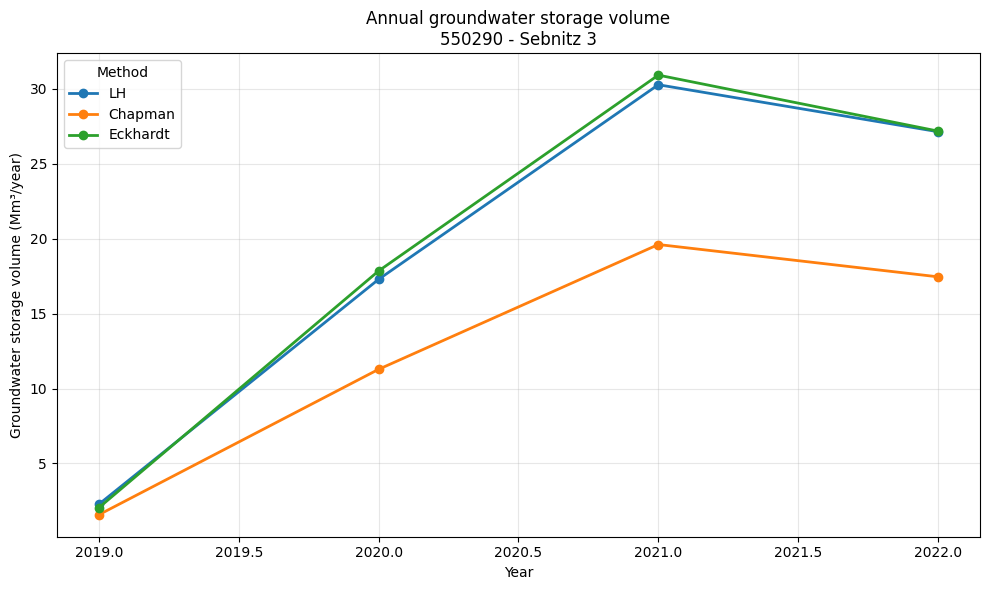

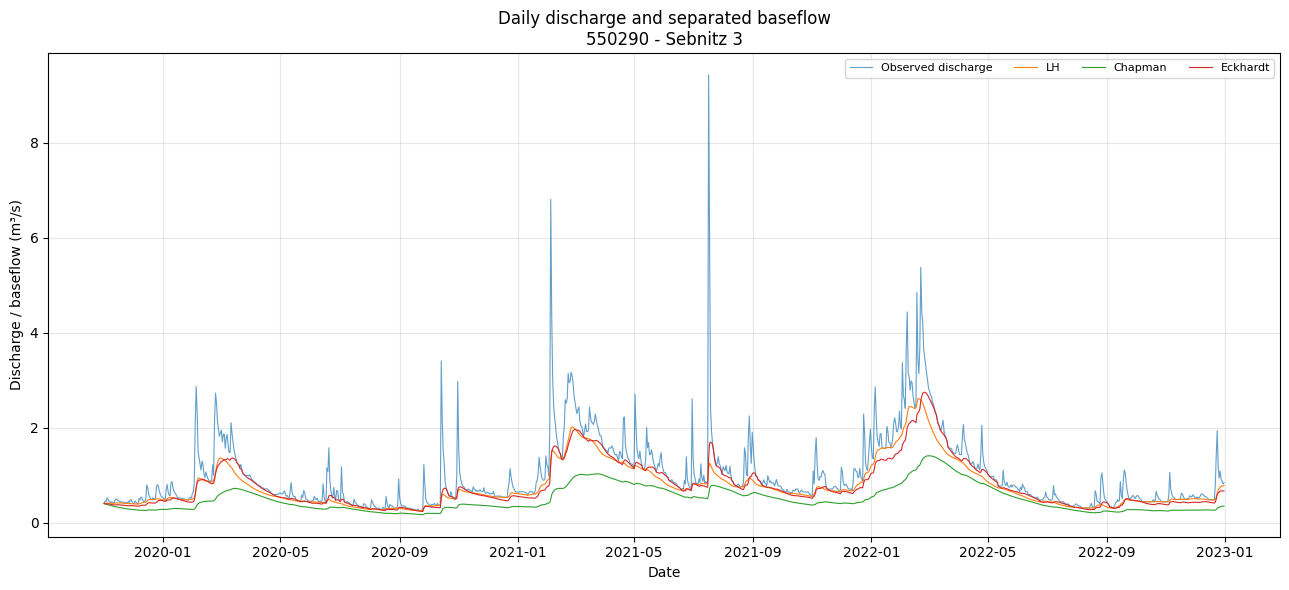


[6/167] Processing station 550390 - Neustadt 1


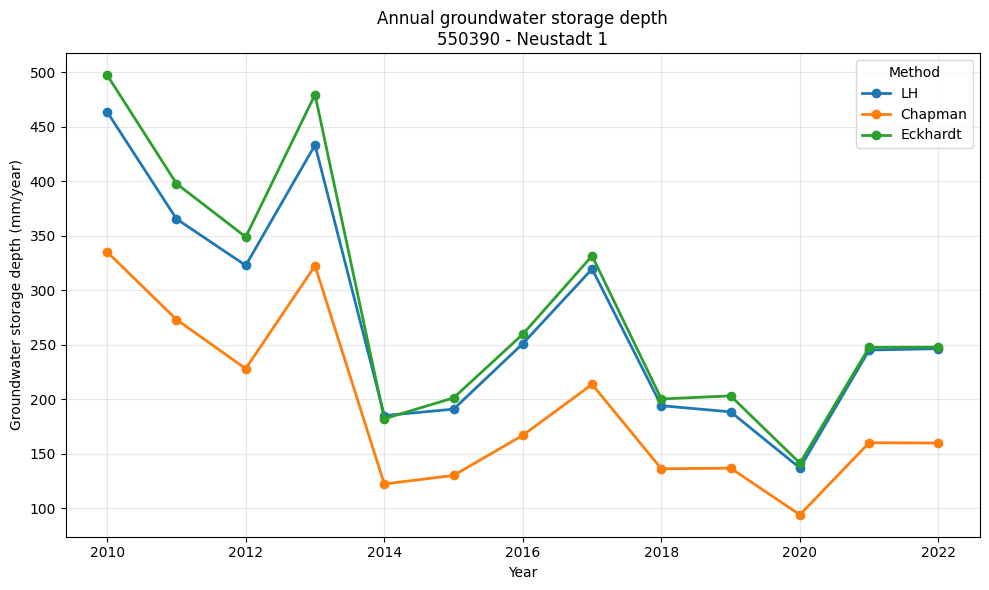

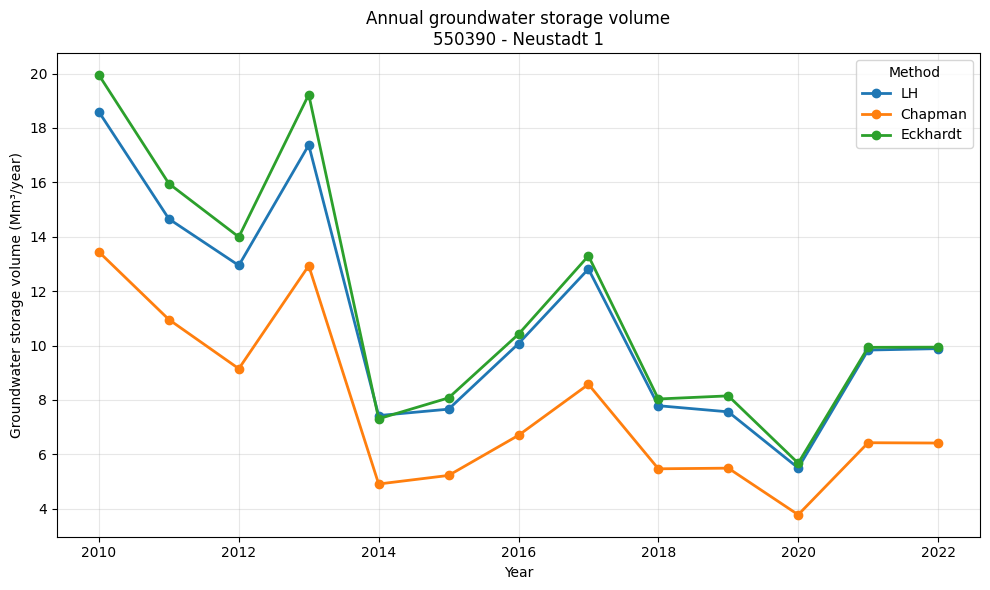

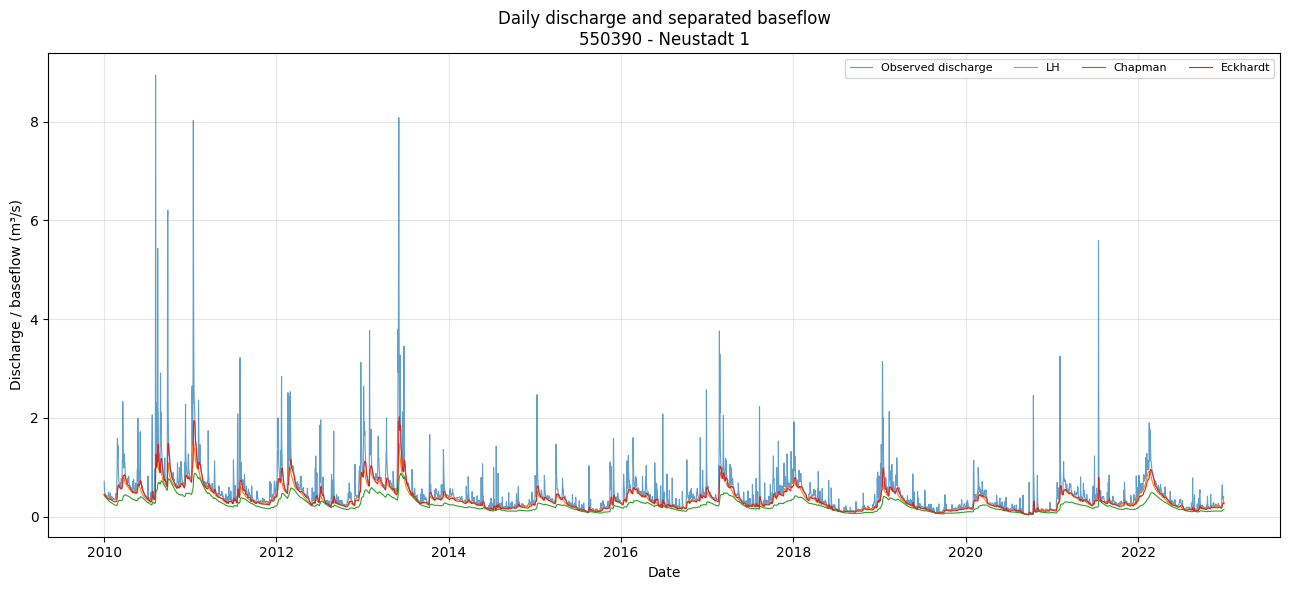


[7/167] Processing station 550490 - Bielatal 1


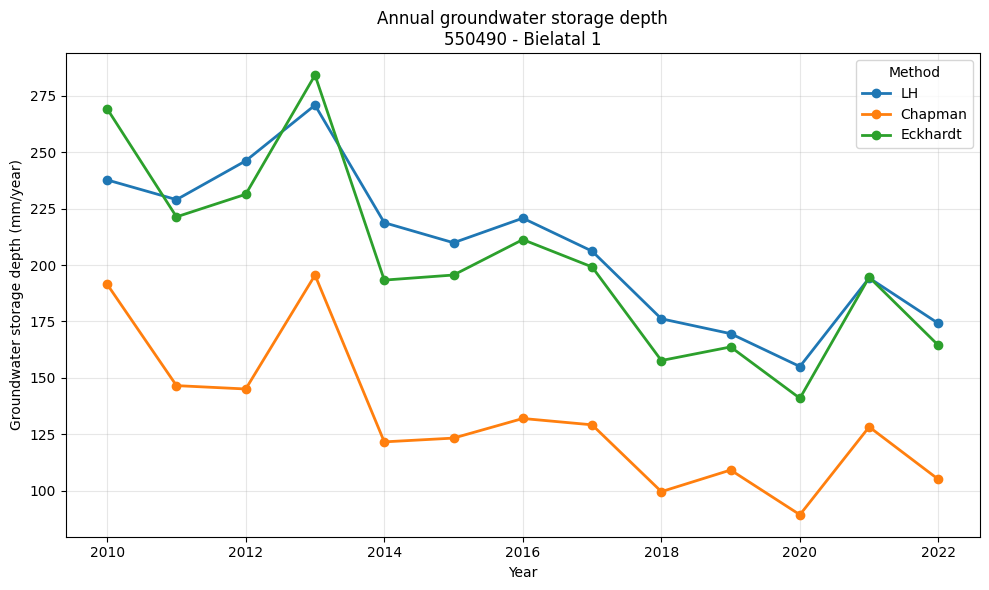

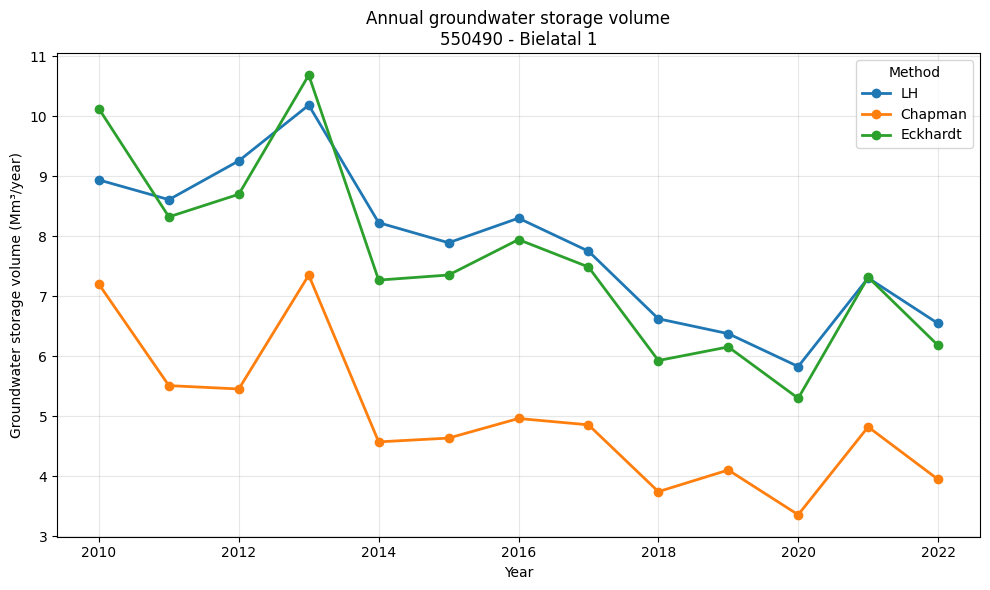

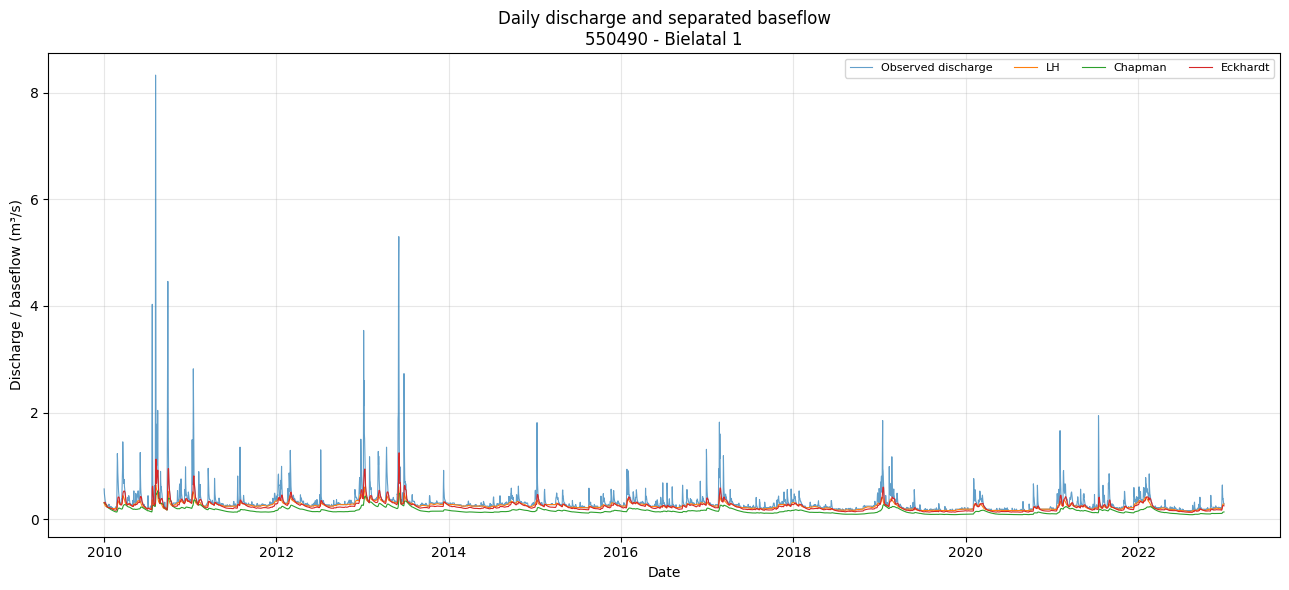


[8/167] Processing station 550560 - Cunnersdorf 1


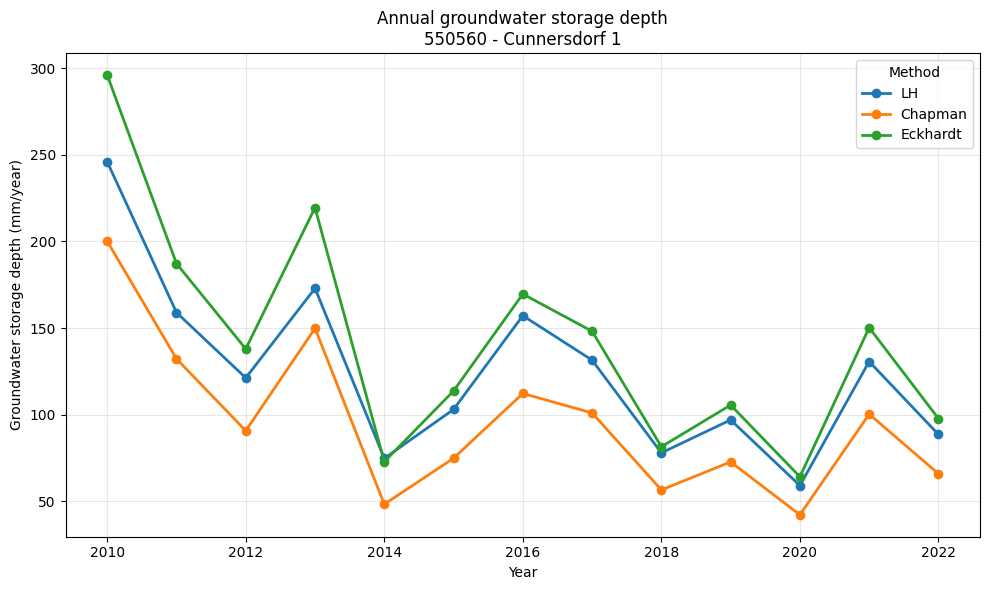

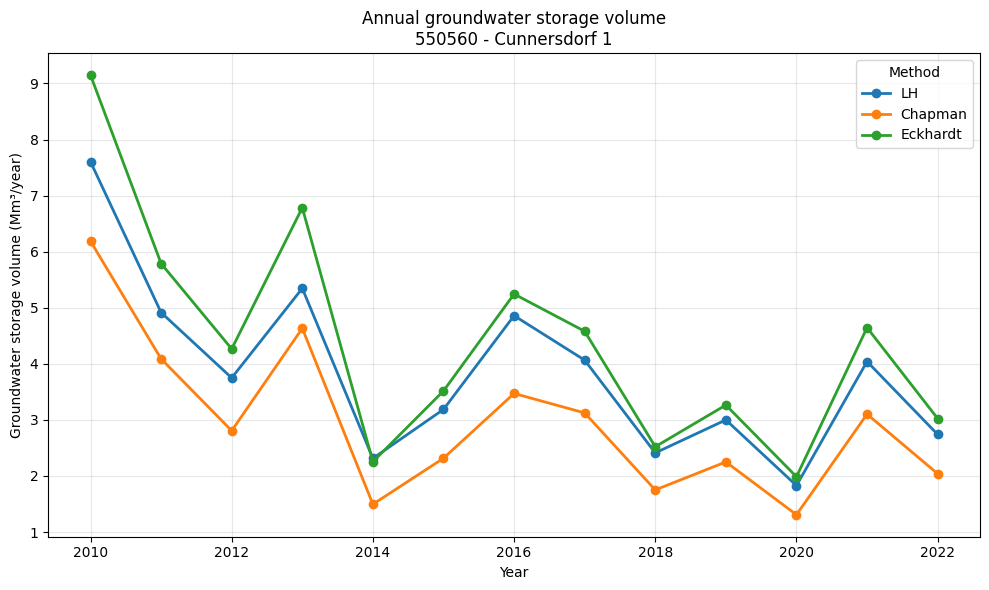

In [ ]:
# ============================================================
# GROUNDWATER STORAGE FROM BASEFLOW SEPARATION
# Study period: 2010-2022
# Methods: LH, Chapman, Eckhardt
#
# Inputs:
# 1. Discharge CSV files:
#    /kaggle/input/datasets/kausar15027/gw-discharge-data/discharge/03_all
#
# 2. Station ID, name, area CSV:
#    /kaggle/input/datasets/kausar15027/station-id/Station_ID.csv
#
# 3. Baseflow package:
#    /kaggle/input/datasets/kausar15027/bfi-measurement
#
# Outputs:
# - Annual groundwater storage in mm/year
# - Annual groundwater storage in Mm3/year
# - CSV files
# - Excel workbook
# - Research-quality plots
# ============================================================

import os
import re
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

baseflow_package_path = "/kaggle/input/datasets/kausar15027/bfi-measurement"
discharge_folder = "/kaggle/input/datasets/kausar15027/gw-discharge-data/discharge/03_all"
station_area_file = "/kaggle/input/datasets/kausar15027/station-id/Station_ID.csv"

output_folder = "/kaggle/working/baseflow_storage_2010_2022"
plots_folder = os.path.join(output_folder, "plots")

Path(output_folder).mkdir(parents=True, exist_ok=True)
Path(plots_folder).mkdir(parents=True, exist_ok=True)

# Add baseflow package path
sys.path.insert(0, baseflow_package_path)

# If the actual package is inside a subfolder, this searches automatically
for root, dirs, files in os.walk(baseflow_package_path):
    if "baseflow" in dirs:
        sys.path.insert(0, root)
        print("Baseflow package path added:", root)
        break

# Import only selected methods
from baseflow.methods import LH, Chapman, Eckhardt

# ------------------------------------------------------------
# 2. PARAMETERS
# ------------------------------------------------------------

START_DATE = "2010-01-01"
END_DATE = "2022-12-31"

# CM removed
METHODS = ["LH", "Chapman", "Eckhardt"]

# Filter parameters
a = 0.98
BFImax = 0.80

# Minimum continuous segment length
MIN_SEGMENT_LENGTH = 30

# Annual data coverage threshold
MIN_DAYS_PER_YEAR = 300

# ------------------------------------------------------------
# 3. HELPER FUNCTIONS
# ------------------------------------------------------------

def extract_station_id(filename):
    """
    Extract station ID from discharge filename.
    Example:
    550290_2019_2024.csv -> 550290
    """
    base = os.path.basename(filename)
    match = re.match(r"(\d+)", base)

    if match:
        return match.group(1)

    return None


def read_csv_flexible(file_path):
    """
    Read CSV with different encodings and separators.
    This helps avoid UnicodeDecodeError.
    """
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252", "ISO-8859-1"]
    separators = [",", ";", "\t"]

    for enc in encodings:
        for sep in separators:
            try:
                df = pd.read_csv(file_path, sep=sep, encoding=enc)

                if df.shape[1] >= 2:
                    return df

            except Exception:
                pass

    # Final fallback
    return pd.read_csv(file_path, encoding="latin1")


def detect_date_column(df):
    """
    Detect date column from discharge CSV.
    """
    possible_date_cols = [
        "Date", "date", "DATE",
        "Time", "time",
        "Datetime", "datetime",
        "Datum", "DATUM"
    ]

    for col in possible_date_cols:
        if col in df.columns:
            return col

    # Fallback: first column
    return df.columns[0]


def detect_discharge_column(df, date_col):
    """
    Detect discharge column.
    """
    possible_q_cols = [
        "Discharge", "discharge", "DISCHARGE",
        "Q", "q",
        "Flow", "flow",
        "Streamflow", "streamflow",
        "Abfluss", "abfluss"
    ]

    for col in df.columns:
        col_clean = str(col).strip()

        for key in possible_q_cols:
            if key.lower() in col_clean.lower() and col != date_col:
                return col

    # Fallback: first numeric column excluding date
    temp = df.drop(columns=[date_col], errors="ignore")

    for col in temp.columns:
        converted = pd.to_numeric(temp[col], errors="coerce")

        if converted.notna().sum() > 0:
            return col

    raise ValueError("No discharge column found.")


def prepare_daily_discharge(csv_file):
    """
    Read discharge CSV, detect columns, convert to daily time series,
    and select 2010-2022 only.
    """
    df = read_csv_flexible(csv_file)
    df.columns = df.columns.astype(str).str.strip()

    date_col = detect_date_column(df)
    q_col = detect_discharge_column(df, date_col)

    df = df[[date_col, q_col]].copy()
    df.columns = ["Date", "Discharge"]

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Discharge"] = pd.to_numeric(df["Discharge"], errors="coerce")

    df = df.dropna(subset=["Date"])
    df = df.sort_values("Date")

    # Remove negative discharge
    df.loc[df["Discharge"] < 0, "Discharge"] = np.nan

    # Convert to daily average
    df = df.set_index("Date")
    df = df.resample("D").mean()

    # Select study period
    df = df.loc[START_DATE:END_DATE].copy()

    # Interpolate only small gaps, maximum 7 days
    df["Discharge"] = df["Discharge"].interpolate(
        method="time",
        limit=7,
        limit_direction="both"
    )

    return df


def apply_baseflow_methods(df):
    """
    Apply LH, Chapman, and Eckhardt baseflow methods
    to continuous valid discharge segments.

    CM is removed because it gives almost the same result as Chapman.
    """
    result = df.copy()

    for method in METHODS:
        result[method] = np.nan

    valid = result["Discharge"].notna()
    group_id = (valid != valid.shift()).cumsum()

    for _, seg in result[valid].groupby(group_id[valid]):

        if len(seg) < MIN_SEGMENT_LENGTH:
            continue

        idx = seg.index
        Q = seg["Discharge"].values.astype(float)

        try:
            # LH baseflow is required as input for Chapman and Eckhardt
            b_LH = LH(Q)

            method_outputs = {
                "LH": b_LH,
                "Chapman": Chapman(Q, b_LH, a),
                "Eckhardt": Eckhardt(Q, b_LH, a, BFImax),
            }

            for method, b in method_outputs.items():
                b = np.asarray(b, dtype=float)

                # Baseflow cannot exceed total discharge
                b = np.minimum(b, Q)

                # Baseflow cannot be negative
                b[b < 0] = np.nan

                result.loc[idx, method] = b

        except Exception as e:
            print(f"Segment failed: {e}")
            continue

    return result


def calculate_annual_storage(bf_df, station_id, station_name, area_km2, file_name):
    """
    Convert daily baseflow discharge to annual groundwater storage.

    Assumption:
    Discharge unit = m3/s
    Area unit = km2

    Annual volume:
    Mm3/year = sum(baseflow * 86400) / 1e6

    Annual depth:
    mm/year = volume_Mm3 / area_km2 * 1000

    Because:
    1 Mm3 over 1 km2 = 1000 mm
    """
    records = []

    df = bf_df.copy()
    df["Year"] = df.index.year

    for year, ydf in df.groupby("Year"):

        total_days = len(ydf)
        discharge_days = int(ydf["Discharge"].notna().sum())

        for method in METHODS:

            method_days = int(ydf[method].notna().sum())

            volume_m3 = (ydf[method] * 86400).sum(skipna=True)
            volume_Mm3 = volume_m3 / 1e6

            if pd.notna(area_km2) and area_km2 > 0:
                depth_mm = (volume_Mm3 / area_km2) * 1000
            else:
                depth_mm = np.nan

            coverage_percent = method_days / total_days * 100 if total_days > 0 else np.nan

            records.append({
                "Station_ID": station_id,
                "Station_Name": station_name,
                "Area_km2": area_km2,
                "File": file_name,
                "Year": int(year),
                "Method": method,
                "GW_storage_mm_year": depth_mm,
                "GW_storage_Mm3_year": volume_Mm3,
                "Valid_days_discharge": discharge_days,
                "Valid_days_method": method_days,
                "Coverage_percent": coverage_percent,
                "Low_coverage_flag": "YES" if method_days < MIN_DAYS_PER_YEAR else "NO"
            })

    return pd.DataFrame(records)


def clean_filename(text):
    """
    Clean station name for file saving.
    """
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", str(text))[:80]


def plot_station_annual_storage(annual_df, station_id, station_name):
    """
    Plot annual GW storage in mm/year and Mm3/year for one station.
    """
    station_dir = os.path.join(
        plots_folder,
        f"{station_id}_{clean_filename(station_name)}"
    )

    Path(station_dir).mkdir(parents=True, exist_ok=True)

    # ---------------------------
    # Plot 1: mm/year
    # ---------------------------
    wide_mm = annual_df.pivot(
        index="Year",
        columns="Method",
        values="GW_storage_mm_year"
    ).sort_index()

    fig, ax = plt.subplots(figsize=(10, 6))

    for method in METHODS:
        if method in wide_mm.columns:
            ax.plot(
                wide_mm.index,
                wide_mm[method],
                marker="o",
                linewidth=2,
                label=method
            )

    ax.set_title(f"Annual groundwater storage depth\n{station_id} - {station_name}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Groundwater storage depth (mm/year)")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Method")
    fig.tight_layout()

    fig.savefig(
        os.path.join(station_dir, f"{station_id}_GW_storage_mm_year.png"),
        dpi=300
    )

    plt.show()
    plt.close(fig)

    # ---------------------------
    # Plot 2: Mm3/year
    # ---------------------------
    wide_vol = annual_df.pivot(
        index="Year",
        columns="Method",
        values="GW_storage_Mm3_year"
    ).sort_index()

    fig, ax = plt.subplots(figsize=(10, 6))

    for method in METHODS:
        if method in wide_vol.columns:
            ax.plot(
                wide_vol.index,
                wide_vol[method],
                marker="o",
                linewidth=2,
                label=method
            )

    ax.set_title(f"Annual groundwater storage volume\n{station_id} - {station_name}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Groundwater storage volume (Mm³/year)")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Method")
    fig.tight_layout()

    fig.savefig(
        os.path.join(station_dir, f"{station_id}_GW_storage_Mm3_year.png"),
        dpi=300
    )

    plt.show()
    plt.close(fig)


def plot_station_daily_baseflow(bf_df, station_id, station_name):
    """
    Plot daily discharge and separated baseflow.
    """
    station_dir = os.path.join(
        plots_folder,
        f"{station_id}_{clean_filename(station_name)}"
    )

    Path(station_dir).mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(13, 6))

    ax.plot(
        bf_df.index,
        bf_df["Discharge"],
        linewidth=0.8,
        alpha=0.7,
        label="Observed discharge"
    )

    for method in METHODS:
        ax.plot(
            bf_df.index,
            bf_df[method],
            linewidth=0.8,
            label=method
        )

    ax.set_title(f"Daily discharge and separated baseflow\n{station_id} - {station_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Discharge / baseflow (m³/s)")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=4, fontsize=8)
    fig.tight_layout()

    fig.savefig(
        os.path.join(station_dir, f"{station_id}_daily_discharge_baseflow.png"),
        dpi=300
    )

    plt.show()
    plt.close(fig)


def plot_overall_results(station_summary, annual_long):
    """
    Create overall research-style plots for all catchments.
    """
    overall_dir = os.path.join(plots_folder, "00_overall_results")
    Path(overall_dir).mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------------
    # Mean storage depth by station
    # --------------------------------------------------------
    pivot_mm = station_summary.pivot_table(
        index="Station_ID",
        columns="Method",
        values="Mean_GW_storage_mm_year",
        aggfunc="mean"
    ).sort_index()

    fig, ax = plt.subplots(figsize=(14, 7))

    pivot_mm.plot(kind="bar", ax=ax)

    ax.set_title("Mean annual groundwater storage depth by catchment, 2010-2022")
    ax.set_xlabel("Station ID")
    ax.set_ylabel("Mean groundwater storage depth (mm/year)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Method")
    fig.tight_layout()

    fig.savefig(
        os.path.join(overall_dir, "mean_GW_storage_depth_all_catchments.png"),
        dpi=300
    )

    plt.show()
    plt.close(fig)

    # --------------------------------------------------------
    # Mean storage volume by station
    # --------------------------------------------------------
    pivot_vol = station_summary.pivot_table(
        index="Station_ID",
        columns="Method",
        values="Mean_GW_storage_Mm3_year",
        aggfunc="mean"
    ).sort_index()

    fig, ax = plt.subplots(figsize=(14, 7))

    pivot_vol.plot(kind="bar", ax=ax)

    ax.set_title("Mean annual groundwater storage volume by catchment, 2010-2022")
    ax.set_xlabel("Station ID")
    ax.set_ylabel("Mean groundwater storage volume (Mm³/year)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Method")
    fig.tight_layout()

    fig.savefig(
        os.path.join(overall_dir, "mean_GW_storage_volume_all_catchments.png"),
        dpi=300
    )

    plt.show()
    plt.close(fig)

    # --------------------------------------------------------
    # Annual regional mean storage depth
    # --------------------------------------------------------
    annual_mean = annual_long.groupby(
        ["Year", "Method"],
        as_index=False
    ).agg(
        Mean_GW_storage_mm_year=("GW_storage_mm_year", "mean"),
        Mean_GW_storage_Mm3_year=("GW_storage_Mm3_year", "mean")
    )

    wide_annual = annual_mean.pivot(
        index="Year",
        columns="Method",
        values="Mean_GW_storage_mm_year"
    ).sort_index()

    fig, ax = plt.subplots(figsize=(11, 6))

    for method in METHODS:
        if method in wide_annual.columns:
            ax.plot(
                wide_annual.index,
                wide_annual[method],
                marker="o",
                linewidth=2,
                label=method
            )

    ax.set_title("Mean annual groundwater storage depth across all catchments")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean groundwater storage depth (mm/year)")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Method")
    fig.tight_layout()

    fig.savefig(
        os.path.join(overall_dir, "annual_mean_GW_storage_depth_all_catchments.png"),
        dpi=300
    )

    plt.show()
    plt.close(fig)


# ------------------------------------------------------------
# 4. READ STATION AREA FILE
# ------------------------------------------------------------

area_df = read_csv_flexible(station_area_file)
area_df.columns = area_df.columns.astype(str).str.strip()

print("Station area file loaded.")
print("Columns found:")
print(area_df.columns.tolist())
print(area_df.head())

# Detect station ID column
station_id_col = None

for col in area_df.columns:
    if "station" in col.lower() and "id" in col.lower():
        station_id_col = col
        break

if station_id_col is None:
    station_id_col = area_df.columns[0]

# Detect station name column
name_col = None

for col in area_df.columns:
    if "name" in col.lower():
        name_col = col
        break

if name_col is None:
    name_col = area_df.columns[1]

# Detect area column
area_col = None

for col in area_df.columns:
    if "area" in col.lower():
        area_col = col
        break

if area_col is None:
    area_col = area_df.columns[2]

area_df = area_df[[station_id_col, name_col, area_col]].copy()
area_df.columns = ["Station_ID", "Station_Name", "Area_km2"]

area_df["Station_ID"] = area_df["Station_ID"].astype(str).str.extract(r"(\d+)")[0]
area_df["Station_Name"] = area_df["Station_Name"].astype(str).str.strip()
area_df["Area_km2"] = pd.to_numeric(area_df["Area_km2"], errors="coerce")

area_df = area_df.dropna(subset=["Station_ID"])
area_df = area_df.drop_duplicates(subset=["Station_ID"])

print("\nCleaned station area table:")
print(area_df.head())

# ------------------------------------------------------------
# 5. READ DISCHARGE FILE LIST AND MATCH WITH STATION FILE
# ------------------------------------------------------------

csv_files = [str(p) for p in Path(discharge_folder).glob("*.csv")]

file_records = []

for file in csv_files:
    sid = extract_station_id(file)

    file_records.append({
        "Station_ID": sid,
        "File": os.path.basename(file),
        "Full_Path": file
    })

files_df = pd.DataFrame(file_records)
files_df = files_df.dropna(subset=["Station_ID"])

matched_df = area_df.merge(files_df, on="Station_ID", how="inner")

matched_df = matched_df[
    ["Station_ID", "Station_Name", "Area_km2", "File", "Full_Path"]
].sort_values("Station_ID")

# Unmatched records
area_only = area_df.loc[
    ~area_df["Station_ID"].isin(files_df["Station_ID"]),
    ["Station_ID", "Station_Name", "Area_km2"]
].copy()

area_only["Reason"] = "Station exists in Station_ID.csv but no matching discharge file found"

file_only = files_df.loc[
    ~files_df["Station_ID"].isin(area_df["Station_ID"]),
    ["Station_ID", "File", "Full_Path"]
].copy()

file_only["Reason"] = "Discharge file exists but station ID not found in Station_ID.csv"

skipped_df = pd.concat([area_only, file_only], ignore_index=True, sort=False)

print("\n====================================================")
print(f"Number of stations in Station_ID.csv: {area_df['Station_ID'].nunique()}")
print(f"Number of discharge CSV files found: {len(files_df)}")
print(f"Number of matched stations to process: {len(matched_df)}")
print(f"Number of unmatched/skipped records: {len(skipped_df)}")
print("====================================================")

print("\nMatched stations preview:")
print(matched_df[["Station_ID", "Station_Name", "Area_km2", "File"]].head(20))

# ------------------------------------------------------------
# 6. RUN BASEFLOW AND STORAGE ANALYSIS
# ------------------------------------------------------------

all_annual_results = []
all_coverage_results = []
error_records = []

for i, row in matched_df.reset_index(drop=True).iterrows():

    station_id = row["Station_ID"]
    station_name = row["Station_Name"]
    area_km2 = row["Area_km2"]
    csv_file = row["Full_Path"]
    file_name = row["File"]

    print(f"\n[{i+1}/{len(matched_df)}] Processing station {station_id} - {station_name}")

    try:
        daily_df = prepare_daily_discharge(csv_file)

        valid_days = int(daily_df["Discharge"].notna().sum())
        total_days = len(daily_df)

        if valid_days < MIN_SEGMENT_LENGTH:
            error_records.append({
                "Station_ID": station_id,
                "Station_Name": station_name,
                "File": file_name,
                "Error": f"Not enough valid discharge data between 2010 and 2022: {valid_days} days"
            })
            continue

        bf_df = apply_baseflow_methods(daily_df)

        annual_df = calculate_annual_storage(
            bf_df=bf_df,
            station_id=station_id,
            station_name=station_name,
            area_km2=area_km2,
            file_name=file_name
        )

        all_annual_results.append(annual_df)

        all_coverage_results.append({
            "Station_ID": station_id,
            "Station_Name": station_name,
            "Area_km2": area_km2,
            "File": file_name,
            "Total_days_2010_2022": total_days,
            "Valid_discharge_days_2010_2022": valid_days,
            "Discharge_coverage_percent": valid_days / total_days * 100 if total_days > 0 else np.nan
        })

        # Save and show plots
        plot_station_annual_storage(annual_df, station_id, station_name)
        plot_station_daily_baseflow(bf_df, station_id, station_name)

    except Exception as e:
        print(f"Failed station {station_id}: {e}")

        error_records.append({
            "Station_ID": station_id,
            "Station_Name": station_name,
            "File": file_name,
            "Error": str(e)
        })

# ------------------------------------------------------------
# 7. COMBINE RESULTS
# ------------------------------------------------------------

if len(all_annual_results) > 0:
    annual_long = pd.concat(all_annual_results, ignore_index=True)
else:
    annual_long = pd.DataFrame(columns=[
        "Station_ID", "Station_Name", "Area_km2", "File", "Year", "Method",
        "GW_storage_mm_year", "GW_storage_Mm3_year",
        "Valid_days_discharge", "Valid_days_method",
        "Coverage_percent", "Low_coverage_flag"
    ])

coverage_df = pd.DataFrame(all_coverage_results)
errors_df = pd.DataFrame(error_records)

# Wide table: mm/year
annual_wide_mm = annual_long.pivot_table(
    index=["Station_ID", "Station_Name", "Area_km2", "Year"],
    columns="Method",
    values="GW_storage_mm_year"
).reset_index()

annual_wide_mm.columns.name = None

# Wide table: Mm3/year
annual_wide_Mm3 = annual_long.pivot_table(
    index=["Station_ID", "Station_Name", "Area_km2", "Year"],
    columns="Method",
    values="GW_storage_Mm3_year"
).reset_index()

annual_wide_Mm3.columns.name = None

# Station summary
if not annual_long.empty:

    station_summary = annual_long.groupby(
        ["Station_ID", "Station_Name", "Area_km2", "Method"],
        as_index=False
    ).agg(
        Mean_GW_storage_mm_year=("GW_storage_mm_year", "mean"),
        Median_GW_storage_mm_year=("GW_storage_mm_year", "median"),
        Min_GW_storage_mm_year=("GW_storage_mm_year", "min"),
        Max_GW_storage_mm_year=("GW_storage_mm_year", "max"),
        Mean_GW_storage_Mm3_year=("GW_storage_Mm3_year", "mean"),
        Median_GW_storage_Mm3_year=("GW_storage_Mm3_year", "median"),
        Min_GW_storage_Mm3_year=("GW_storage_Mm3_year", "min"),
        Max_GW_storage_Mm3_year=("GW_storage_Mm3_year", "max"),
        First_year=("Year", "min"),
        Last_year=("Year", "max"),
        Number_of_years=("Year", "nunique"),
        Mean_coverage_percent=("Coverage_percent", "mean")
    )

    method_summary = annual_long.groupby(
        "Method",
        as_index=False
    ).agg(
        Mean_GW_storage_mm_year=("GW_storage_mm_year", "mean"),
        Median_GW_storage_mm_year=("GW_storage_mm_year", "median"),
        Mean_GW_storage_Mm3_year=("GW_storage_Mm3_year", "mean"),
        Median_GW_storage_Mm3_year=("GW_storage_Mm3_year", "median"),
        Number_of_stations=("Station_ID", "nunique"),
        Number_of_years=("Year", "nunique")
    )

else:
    station_summary = pd.DataFrame()
    method_summary = pd.DataFrame()

# ------------------------------------------------------------
# 8. SAVE CSV OUTPUTS
# ------------------------------------------------------------

annual_long_csv = os.path.join(output_folder, "annual_GW_storage_long_2010_2022.csv")
annual_wide_mm_csv = os.path.join(output_folder, "annual_GW_storage_mm_year_2010_2022.csv")
annual_wide_Mm3_csv = os.path.join(output_folder, "annual_GW_storage_Mm3_year_2010_2022.csv")
station_summary_csv = os.path.join(output_folder, "station_summary_GW_storage_2010_2022.csv")
method_summary_csv = os.path.join(output_folder, "method_summary_GW_storage_2010_2022.csv")
matched_csv = os.path.join(output_folder, "matched_stations.csv")
skipped_csv = os.path.join(output_folder, "skipped_unmatched_stations.csv")
coverage_csv = os.path.join(output_folder, "data_coverage_summary.csv")
errors_csv = os.path.join(output_folder, "errors_or_skipped.csv")

annual_long.to_csv(annual_long_csv, index=False)
annual_wide_mm.to_csv(annual_wide_mm_csv, index=False)
annual_wide_Mm3.to_csv(annual_wide_Mm3_csv, index=False)
station_summary.to_csv(station_summary_csv, index=False)
method_summary.to_csv(method_summary_csv, index=False)
matched_df.to_csv(matched_csv, index=False)
skipped_df.to_csv(skipped_csv, index=False)
coverage_df.to_csv(coverage_csv, index=False)
errors_df.to_csv(errors_csv, index=False)

# ------------------------------------------------------------
# 9. SAVE EXCEL OUTPUT
# ------------------------------------------------------------

excel_file = os.path.join(output_folder, "GW_storage_2010_2022_all_results.xlsx")

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:

    annual_long.to_excel(writer, sheet_name="Annual_Long", index=False)
    annual_wide_mm.to_excel(writer, sheet_name="Annual_mm_year", index=False)
    annual_wide_Mm3.to_excel(writer, sheet_name="Annual_Mm3_year", index=False)
    station_summary.to_excel(writer, sheet_name="Station_Summary", index=False)
    method_summary.to_excel(writer, sheet_name="Method_Summary", index=False)
    matched_df.to_excel(writer, sheet_name="Matched_Stations", index=False)
    skipped_df.to_excel(writer, sheet_name="Skipped_Unmatched", index=False)
    coverage_df.to_excel(writer, sheet_name="Coverage", index=False)
    errors_df.to_excel(writer, sheet_name="Errors", index=False)

    for sheet_name in writer.sheets:
        ws = writer.sheets[sheet_name]
        ws.freeze_panes = "A2"

        for column_cells in ws.columns:
            max_length = 0
            column_letter = column_cells[0].column_letter

            for cell in column_cells:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))

            ws.column_dimensions[column_letter].width = min(max_length + 2, 35)

# ------------------------------------------------------------
# 10. SAVE OVERALL PLOTS
# ------------------------------------------------------------

if not annual_long.empty:
    plot_overall_results(station_summary, annual_long)

# ------------------------------------------------------------
# 11. FINAL MESSAGE
# ------------------------------------------------------------

print("\n====================================================")
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("====================================================")

print("\nMain output folder:")
print(output_folder)

print("\nCSV files saved:")
print(annual_long_csv)
print(annual_wide_mm_csv)
print(annual_wide_Mm3_csv)
print(station_summary_csv)
print(method_summary_csv)

print("\nExcel file saved:")
print(excel_file)

print("\nPlots saved in:")
print(plots_folder)

print("\nNumber of matched stations processed:")
print(len(matched_df))

print("\nNumber of stations with successful annual results:")
print(annual_long["Station_ID"].nunique() if not annual_long.empty else 0)

print("\nNumber of error/skipped records:")
print(len(errors_df))

if len(errors_df) > 0:
    print("\nSome stations had errors. Please check:")
    print(errors_csv)

print("====================================================")

In [ ]:
# ============================================================
# 8. PLOT: METHOD COMPARISON BOXPLOT
# ============================================================

method_order = ["LH", "CM", "Chapman", "Eckhardt"]
plot_df = annual_long[annual_long["Method"].isin(method_order)].copy()

data = [
    plot_df.loc[plot_df["Method"] == method, "GW_storage_mm_year"].dropna().values
    for method in method_order
]

fig, ax = plt.subplots(figsize=(9, 6))

box = ax.boxplot(
    data,
    labels=method_order,
    patch_artist=True,
    showmeans=True
)

ax.set_title(
    "Distribution of Annual Groundwater Storage Depth by Method",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Baseflow separation method", fontsize=12)
ax.set_ylabel("Groundwater storage depth (mm/year)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()

out_fig = os.path.join(plots_folder, "05_method_comparison_boxplot_GW_storage_depth.png")
plt.savefig(out_fig, dpi=400, bbox_inches="tight")
plt.show()

print("Saved plot:", out_fig)

In [ ]:
# ============================================================
# 9. PLOT: HEATMAP OF ANNUAL GW STORAGE DEPTH
# Main method: Eckhardt
# ============================================================

main_method = "Eckhardt"

heat_df = annual_long[annual_long["Method"] == main_method].copy()

heat_df["Station_Label"] = (
    heat_df["Station_ID"].astype(str) + " - " + heat_df["Station_Name"].astype(str)
)

heat_table = heat_df.pivot_table(
    index="Station_Label",
    columns="Year",
    values="GW_storage_mm_year",
    aggfunc="mean"
)

# Sort by mean storage
heat_table["Mean"] = heat_table.mean(axis=1)
heat_table = heat_table.sort_values("Mean", ascending=False)
heat_table = heat_table.drop(columns=["Mean"])

fig, ax = plt.subplots(figsize=(13, max(6, 0.35 * len(heat_table))))

im = ax.imshow(
    heat_table.values,
    aspect="auto"
)

ax.set_title(
    f"Annual Groundwater Storage Depth Heatmap ({main_method} Method)",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Catchment / Station", fontsize=12)

ax.set_xticks(np.arange(len(heat_table.columns)))
ax.set_xticklabels(heat_table.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(len(heat_table.index)))
ax.set_yticklabels(heat_table.index, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Groundwater storage depth (mm/year)", fontsize=11)

plt.tight_layout()

out_fig = os.path.join(plots_folder, f"06_heatmap_GW_storage_depth_{main_method}.png")
plt.savefig(out_fig, dpi=400, bbox_inches="tight")
plt.show()

print("Saved plot:", out_fig)

In [ ]:
# ============================================================
# 11. ZIP ALL OUTPUTS FOR DOWNLOAD
# ============================================================

import shutil

zip_path = "/kaggle/working/baseflow_storage_2010_2022_outputs"

shutil.make_archive(
    zip_path,
    "zip",
    output_folder
)

print("ZIP file created:")
print(zip_path + ".zip")